In [1]:
source("/workspaces/estudo_de_adequabilidade_de_poder_de_teste/funcoes_final_nao_proporcionais.R", local = FALSE, echo = FALSE, print.eval = FALSE)


Attaching package: ‘survival’


The following object is masked from ‘package:Rlab’:

    cancer


Loading required package: ggpubr


Attaching package: ‘survminer’


The following object is masked from ‘package:survival’:

    myeloma




In [2]:
### =========================================== APLICACAO ======================= ###
n <- 300
pi <- 0.5

# Ajuste para riscos não proporcionais
distribuicao <- "weibull"

# --- GRUPO EXPERIMENTAL (A) ---
shape_falha_experimental_weibull <- 0.5
parametro_falha_experimental <- 2.0 
parametro_censura_experimental <- 10.89
shape_censura_experimental_weibull <- shape_falha_experimental_weibull

# --- GRUPO CONTROLE (B) ---
shape_falha_controle_weibull <- 2.0
parametro_falha_controle <- 4.0
parametro_censura_controle <- 6.11
shape_censura_controle_weibull <- shape_falha_controle_weibull

In [3]:
dados <- exemplo(distribuicao, n, pi, 
                    parametro_falha_experimental, parametro_falha_controle, 
                    parametro_censura_experimental, parametro_censura_controle,
                    shape_falha_experimental_weibull, shape_censura_experimental_weibull, 
                    shape_falha_controle_weibull, shape_censura_controle_weibull, 
                    sdlog_falha_experimental, sdlog_censura_experimental, 
                    sdlog_falha_controle, sdlog_censura_controle)

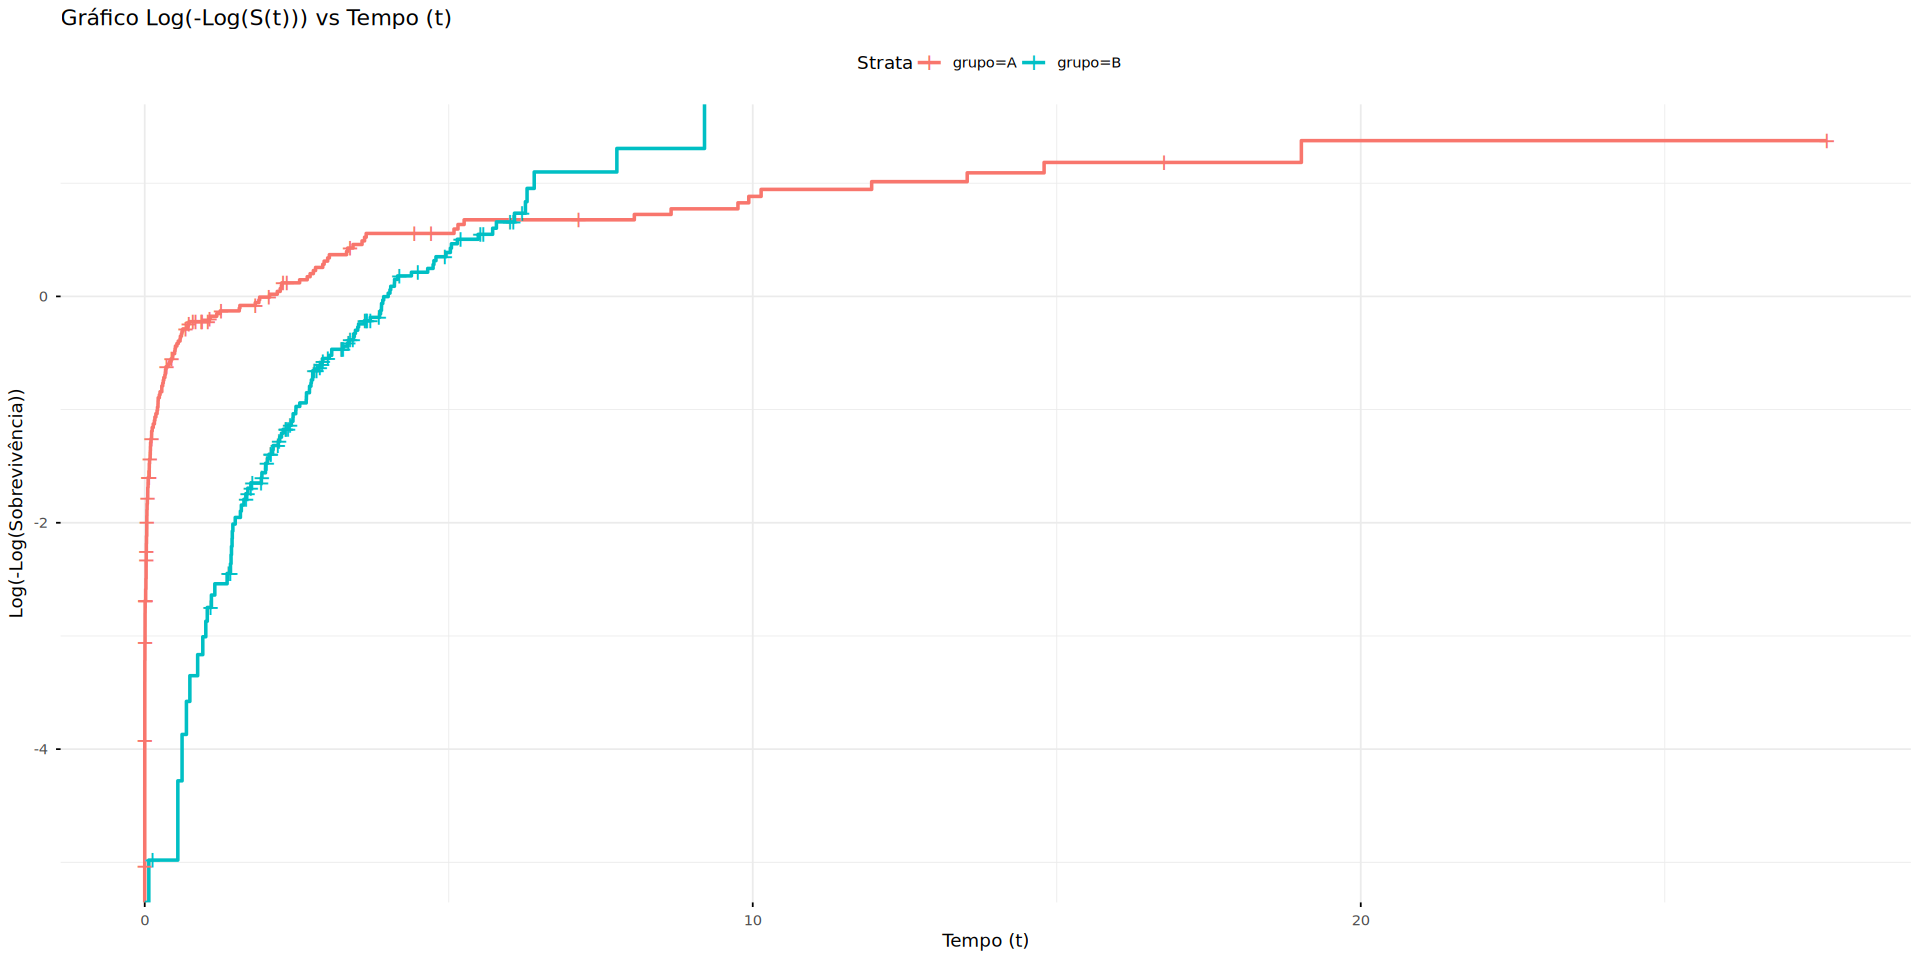

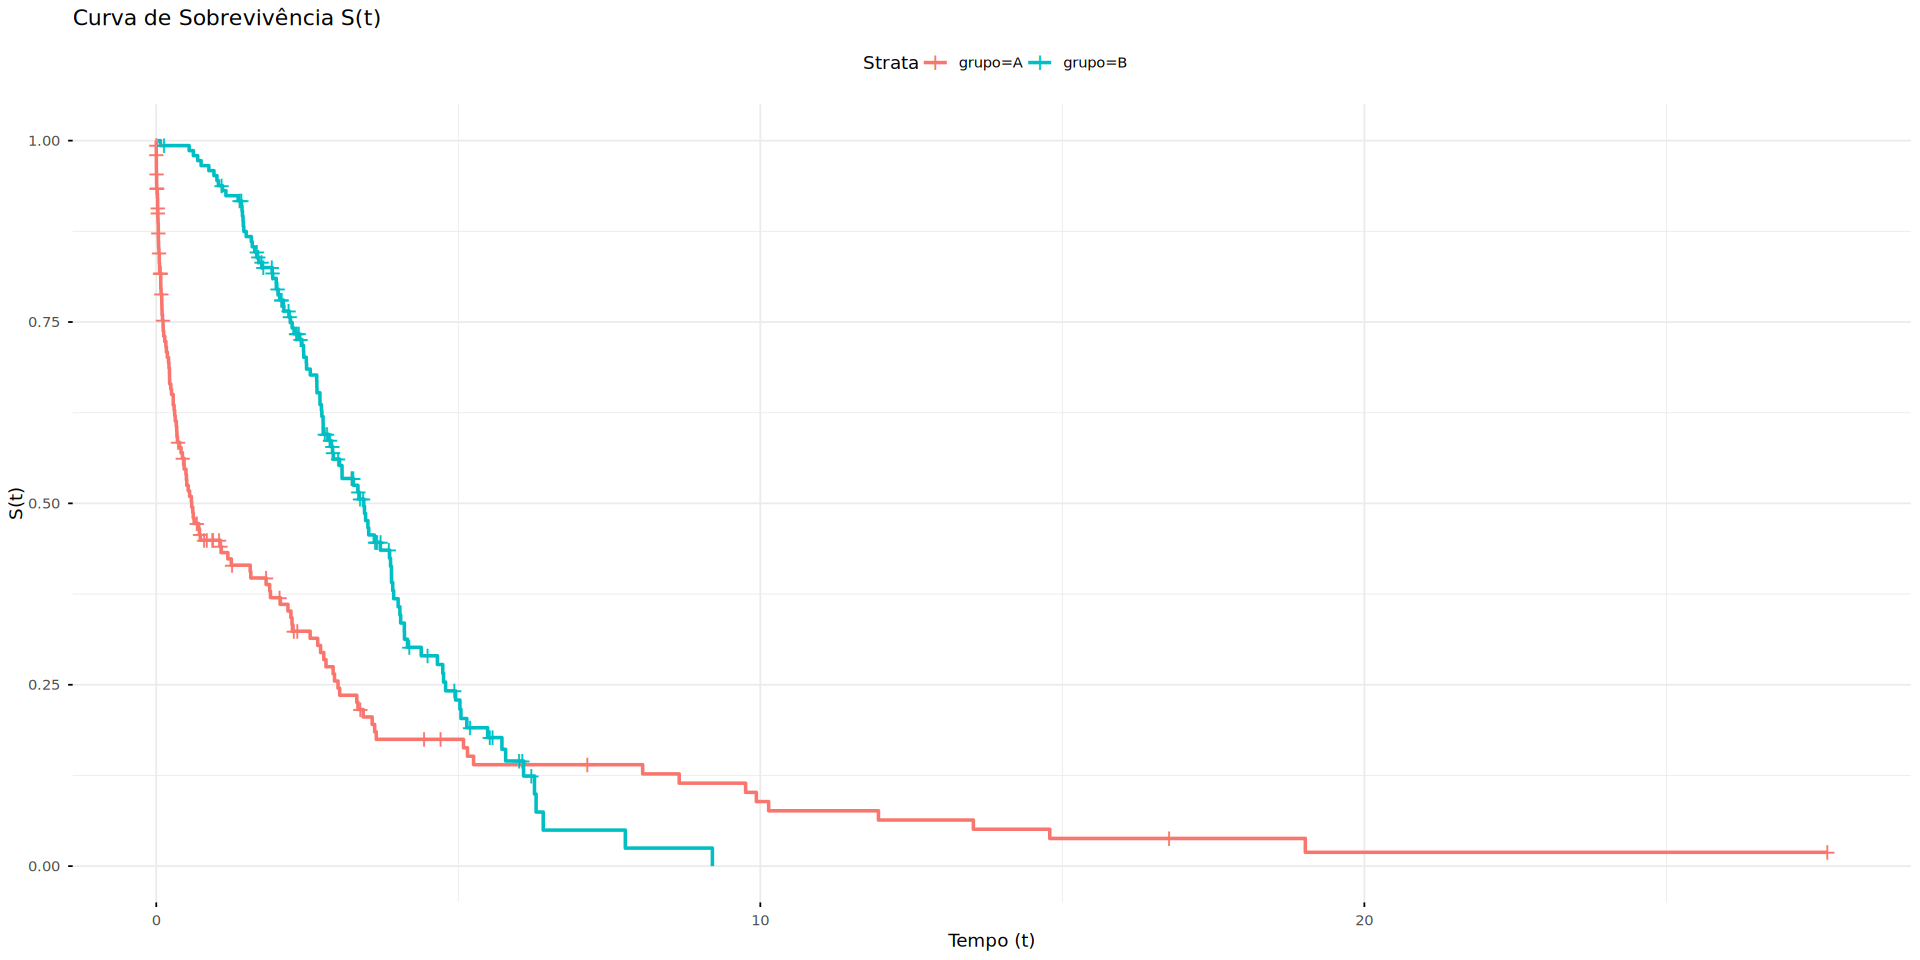

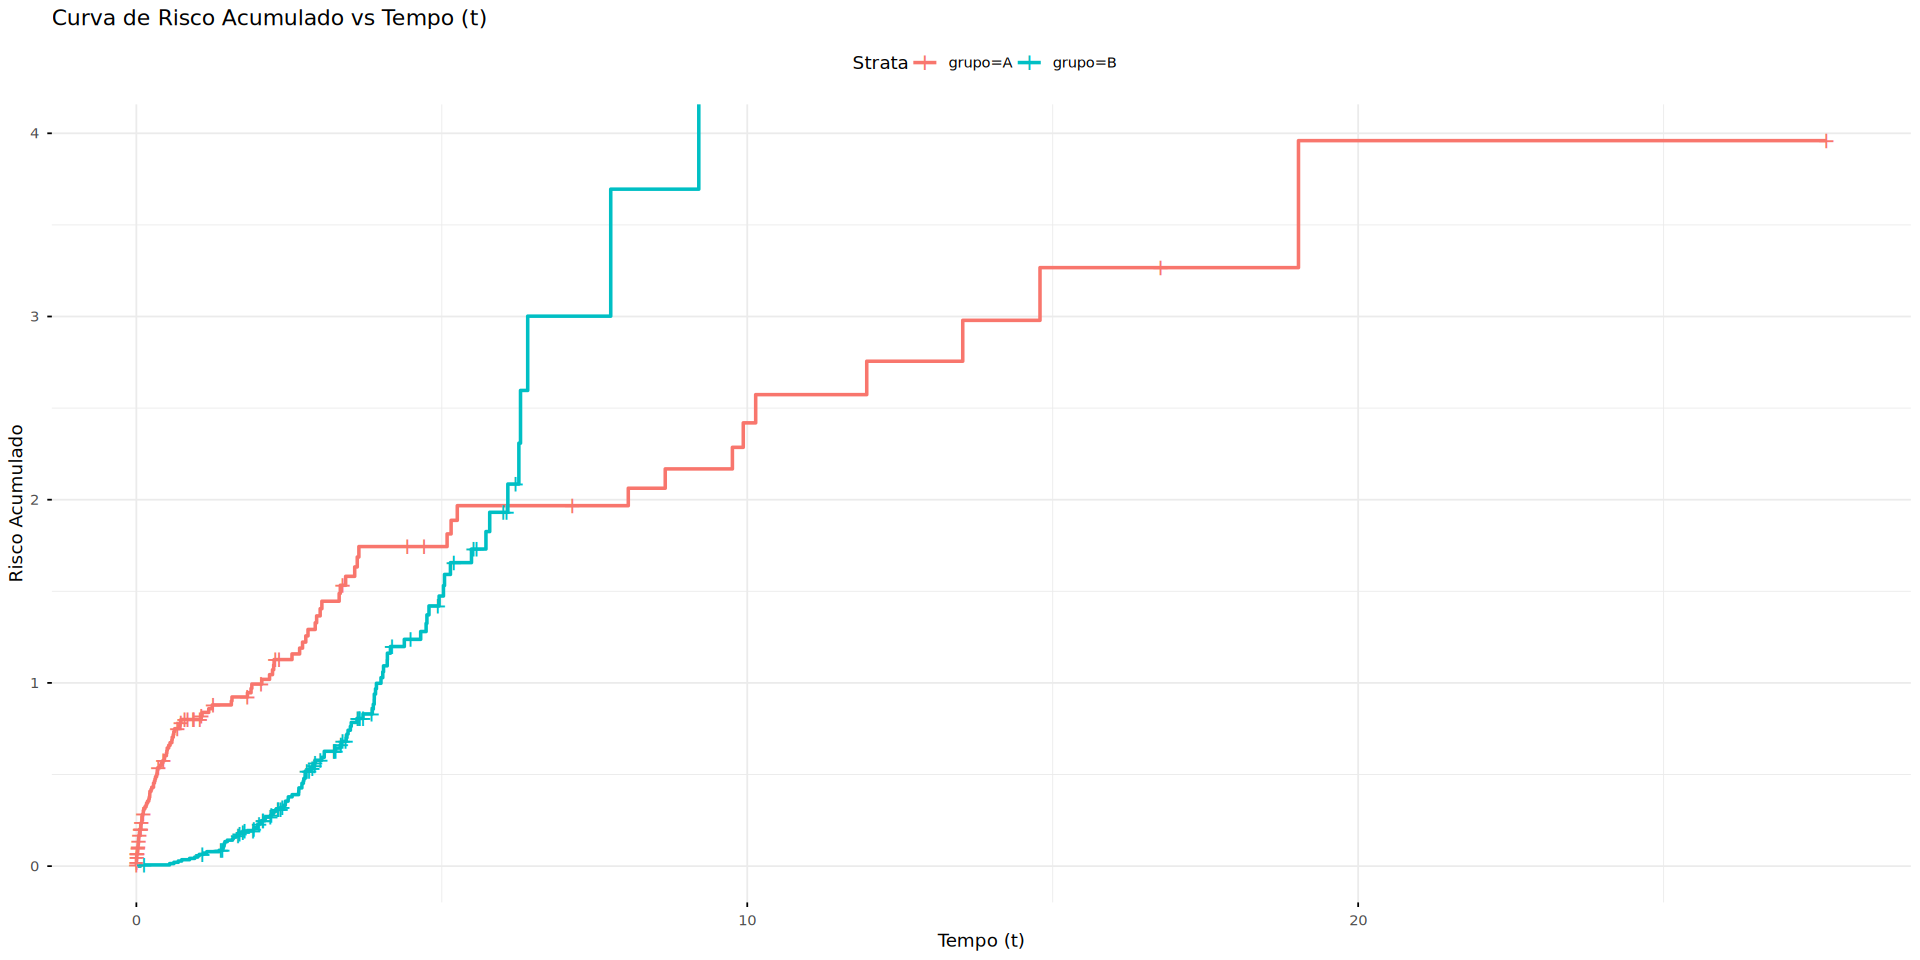

In [12]:
# 1. Definir os parâmetros de escala baseados nos seus dados (como feito anteriormente)
tempo_maximo <- max(dados$z, na.rm = TRUE)
intervalo_tempo <- 10 # Ajuste este valor conforme a necessidade visual dos seus dados
curva <- survfit(Surv(z, delta) ~ grupo, data = dados)
# ---------------------------------------------------------
# Gráfico 1: Log(-Log(S(t)))
# ---------------------------------------------------------
# Pegando o menor tempo maior que zero (para evitar log de zero)
tempo_minimo <- min(dados$z[dados$z > 0], na.rm = TRUE)
# Ou você pode simplesmente fixar em 1, ex: tempo_minimo <- 1

grafico_cloglog <- ggsurvplot(
  curva, 
  # Passamos a fórmula manualmente para impedir a escala logarítmica no eixo X
  fun = function(y) log(-log(y)), 
  ggtheme = theme_minimal(),
  title = "Gráfico Log(-Log(S(t))) vs Tempo (t)",
  xlab = "Tempo (t)", 
  ylab = "Log(-Log(Sobrevivência))",
  xlim = c(0, tempo_maximo),         # Agora você pode usar o 0 como início de novo
  break.time.by = intervalo_tempo    # Os intervalos de 10 em 10 terão o mesmo tamanho físico
)

# ---------------------------------------------------------
# Gráfico 2: Curva de Sobrevivência S(t)
# ---------------------------------------------------------
grafico_sobrevivencia <- ggsurvplot(
  curva,
  conf.int = FALSE,
  risk.table = FALSE,
  ggtheme = theme_minimal(),
  title = "Curva de Sobrevivência S(t)",
  xlab = "Tempo (t)",
  ylab = "S(t)",
  xlim = c(0, tempo_maximo),
  break.time.by = intervalo_tempo
)

# ---------------------------------------------------------
# Gráfico 3: Curva de Risco Acumulado (Cumulative Hazard)
# ---------------------------------------------------------
grafico_risco <- ggsurvplot(
  curva,
  fun = "cumhaz", # Este argumento plota o risco acumulado H(t) = -log(S(t))
  conf.int = FALSE,
  risk.table = FALSE,
  ggtheme = theme_minimal(),
  title = "Curva de Risco Acumulado vs Tempo (t)",
  xlab = "Tempo (t)",
  ylab = "Risco Acumulado",
  xlim = c(0, tempo_maximo),         # Utiliza os mesmos limites no eixo X
  break.time.by = intervalo_tempo    # Utiliza os mesmos intervalos
)

# Para visualizar os gráficos separadamente:
grafico_cloglog$plot
grafico_sobrevivencia$plot
grafico_risco$plot

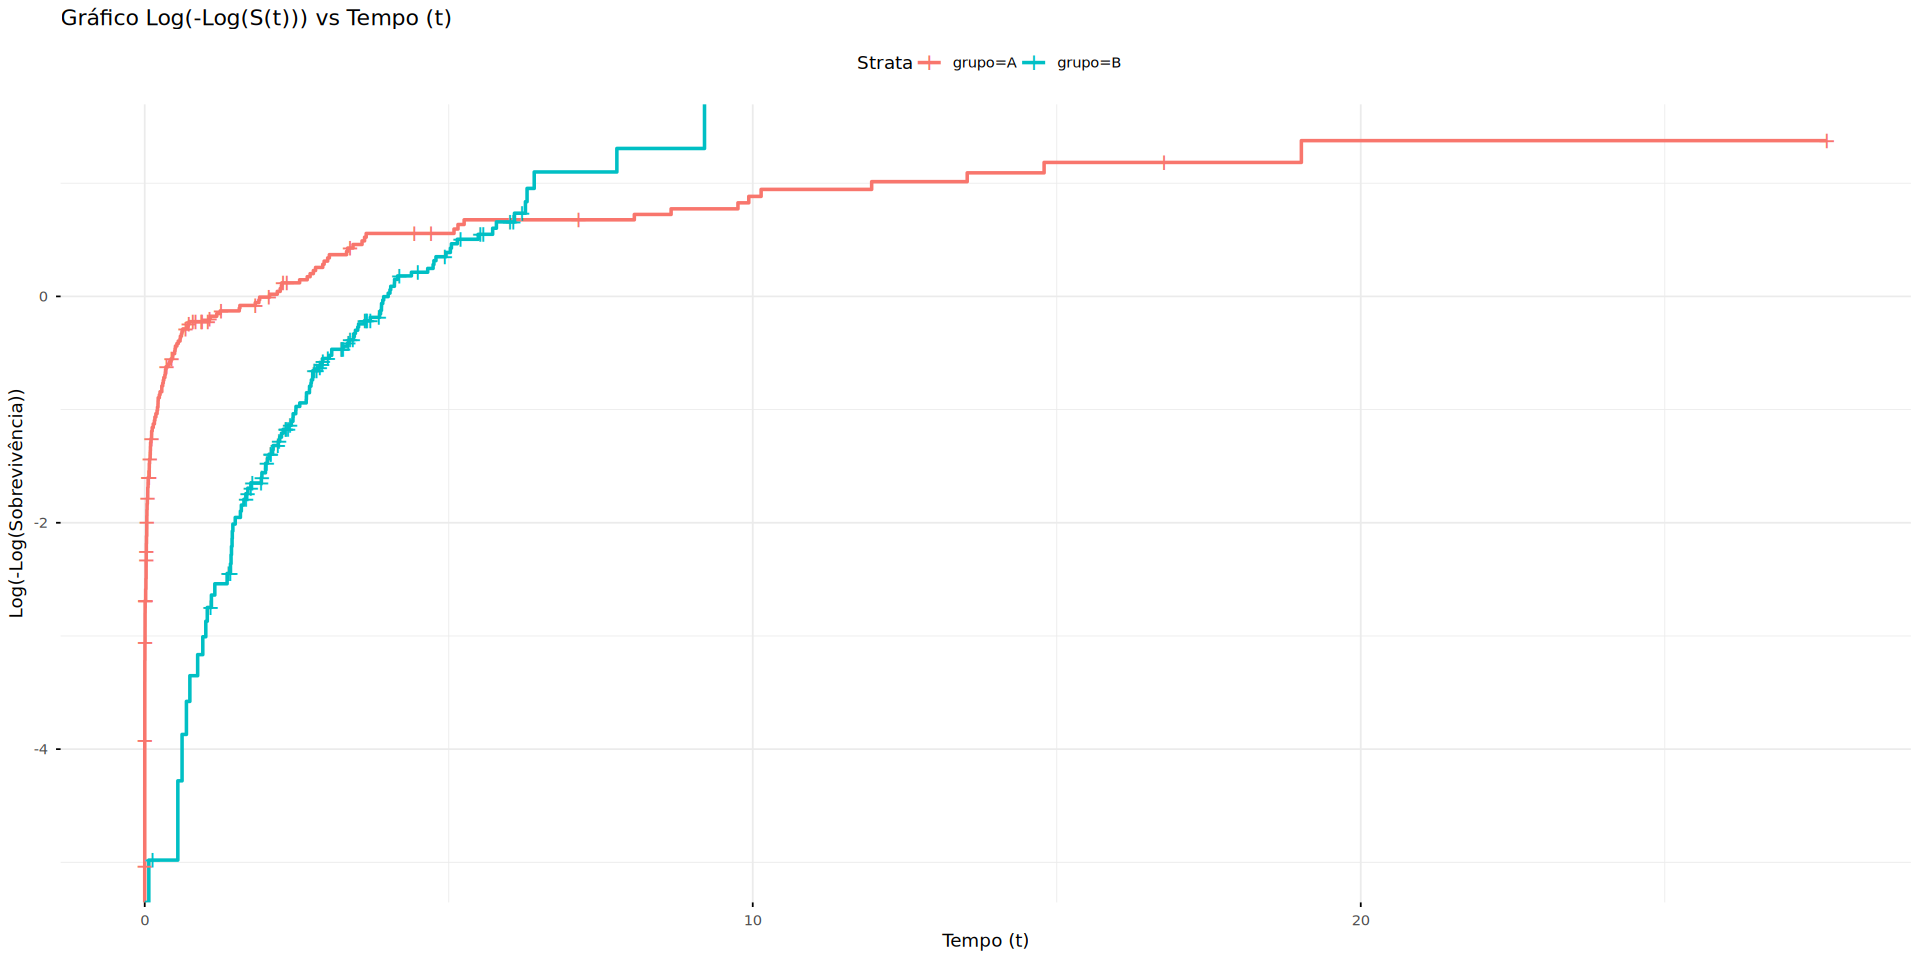

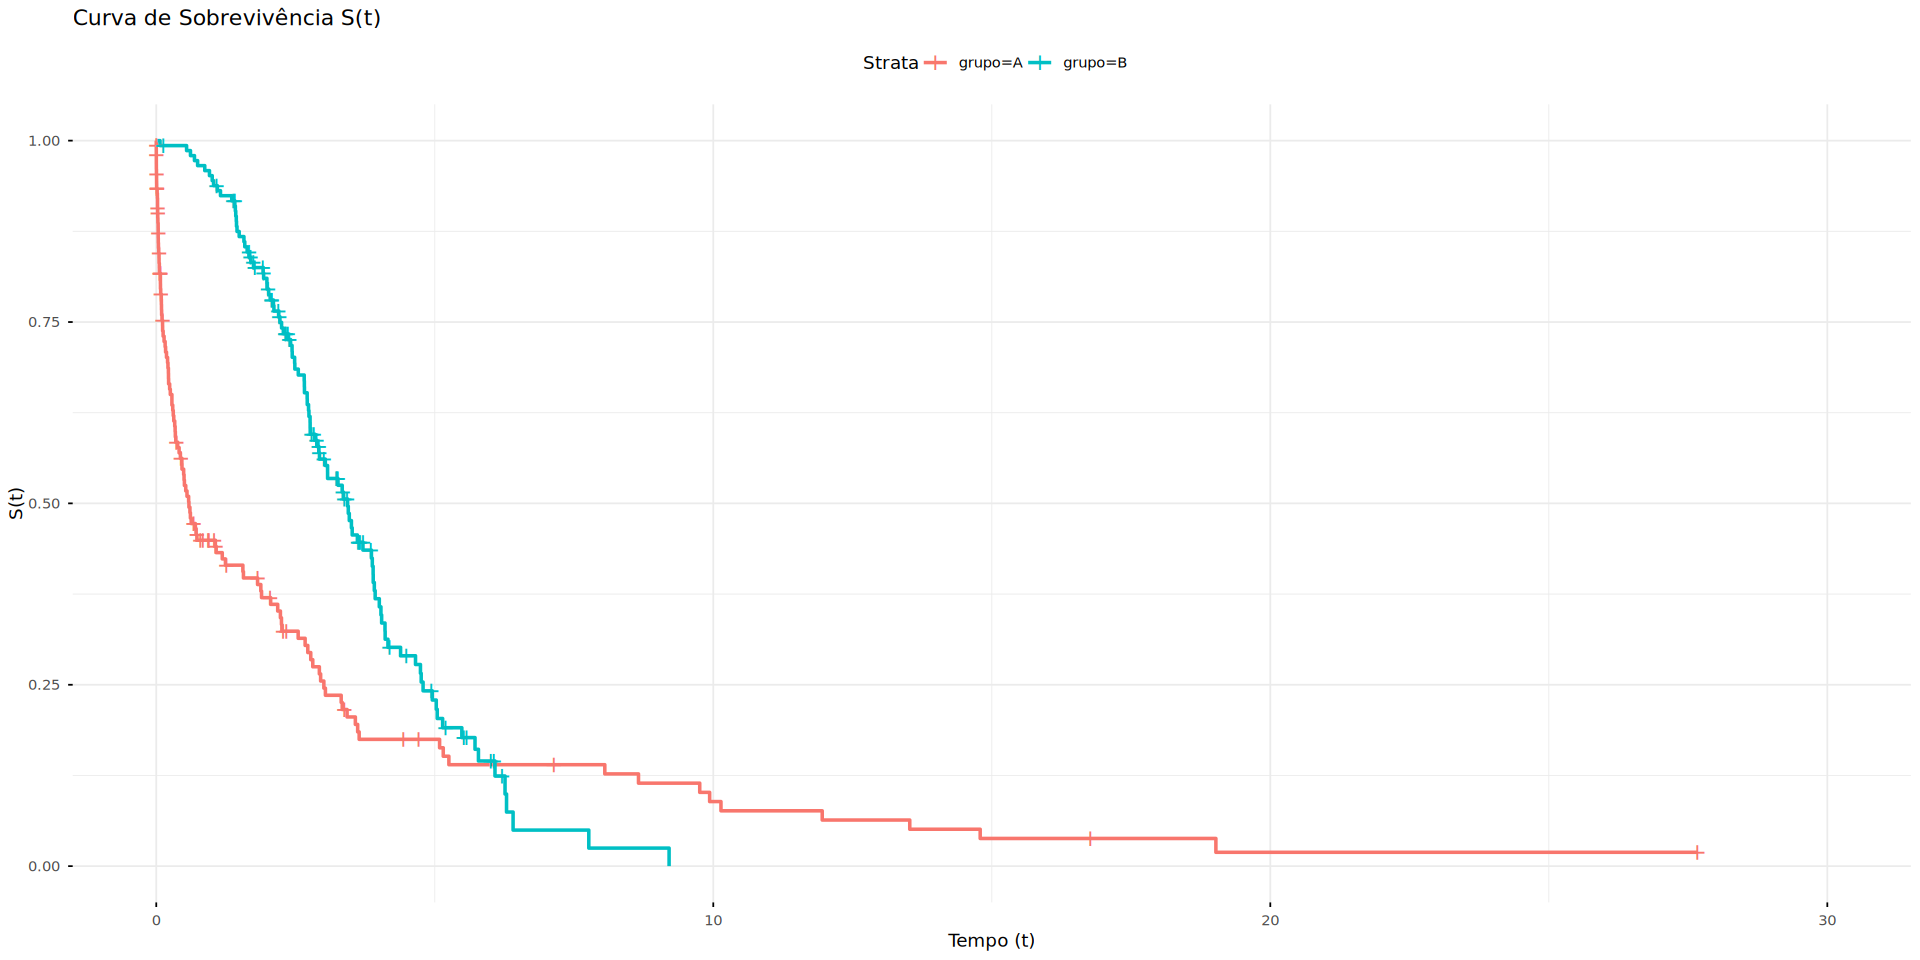

In [ ]:
curva <- survfit(Surv(z, delta) ~ grupo, data = dados)
ggsurvplot(curva, 
           fun = "cloglog",   # Aplica log(-log(S(t))) no eixo Y
           # Não usamos nenhum argumento de log para o eixo X
           ggtheme = theme_minimal(),
           title = "Gráfico Log(-Log(S(t))) vs Tempo (t)",
           xlab = "Tempo (t)", 
           ylab = "Log(-Log(Sobrevivência))")

ggsurvplot(
  curva,
  conf.int = FALSE,
  risk.table = FALSE,
  ggtheme = theme_minimal(),
  title = "Curva de Sobrevivência S(t)",
  xlab = "Tempo (t)",
  ylab = "S(t)"
)$plot

Processando n = 20 

=== Relatório | n = 20 ===
Grupo Experimental (A) - Censura Média: 31.5%
Grupo Controle (B) - Censura Média: 29.7%
Processando n = 40 

=== Relatório | n = 40 ===
Grupo Experimental (A) - Censura Média: 29.2%
Grupo Controle (B) - Censura Média: 30.2%
Processando n = 60 

=== Relatório | n = 60 ===
Grupo Experimental (A) - Censura Média: 29.8%
Grupo Controle (B) - Censura Média: 29.6%
Processando n = 80 

=== Relatório | n = 80 ===
Grupo Experimental (A) - Censura Média: 30.8%
Grupo Controle (B) - Censura Média: 30.0%
Processando n = 100 

=== Relatório | n = 100 ===
Grupo Experimental (A) - Censura Média: 29.9%
Grupo Controle (B) - Censura Média: 29.7%
Processando n = 120 

=== Relatório | n = 120 ===
Grupo Experimental (A) - Censura Média: 30.0%
Grupo Controle (B) - Censura Média: 30.1%
Processando n = 140 

=== Relatório | n = 140 ===
Grupo Experimental (A) - Censura Média: 29.9%
Grupo Controle (B) - Censura Média: 29.8%
Processando n = 160 

=== Relatório | n = 

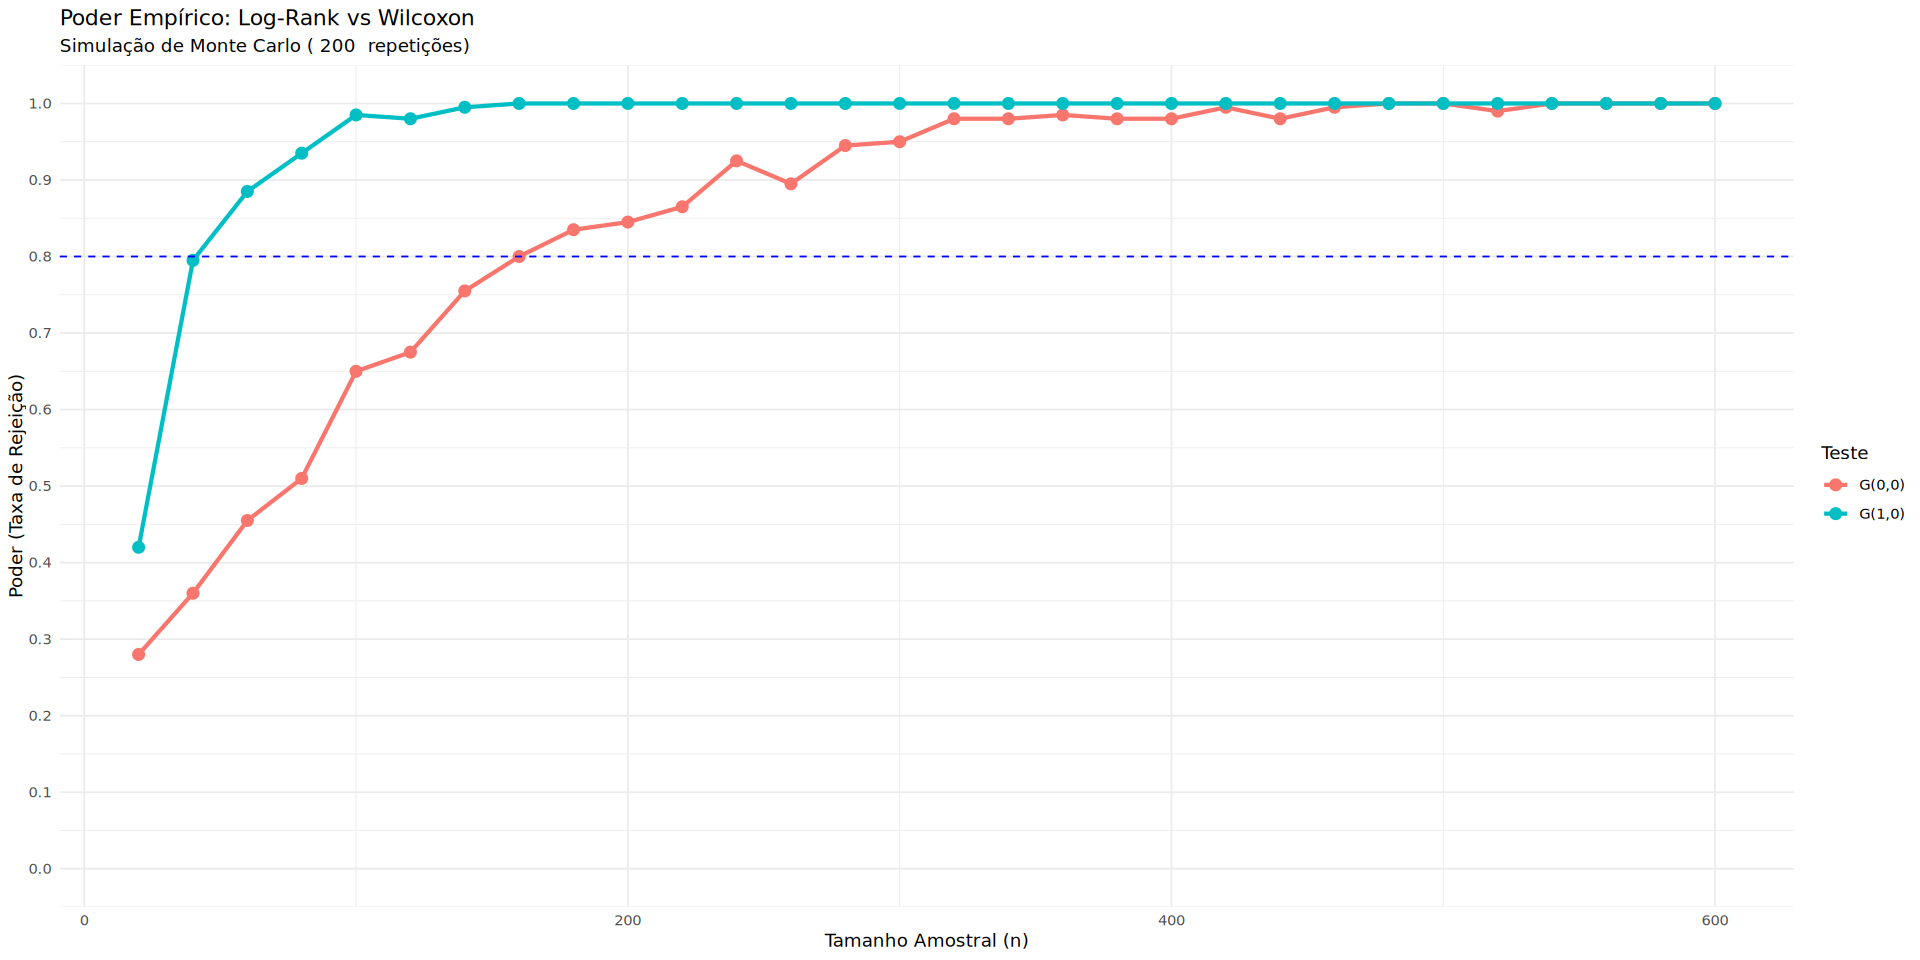

In [11]:
simulacao_amostral_empirica(n_sim = 200, 
                            ns = seq(20, 600, by = 20),
                            rho1 = 0, eta1 = 0,
                            rho2 = 1, eta2 = 0, 
                            alpha = 0.05) 

Processando n = 20 

=== Relatório | n = 20 ===
Grupo Experimental (A) - Censura Média: 28.3%
Grupo Controle (B) - Censura Média: 30.7%
Processando n = 40 

=== Relatório | n = 40 ===
Grupo Experimental (A) - Censura Média: 29.5%
Grupo Controle (B) - Censura Média: 30.8%
Processando n = 60 

=== Relatório | n = 60 ===
Grupo Experimental (A) - Censura Média: 29.6%
Grupo Controle (B) - Censura Média: 29.4%
Processando n = 80 

=== Relatório | n = 80 ===
Grupo Experimental (A) - Censura Média: 29.7%
Grupo Controle (B) - Censura Média: 29.8%
Processando n = 100 

=== Relatório | n = 100 ===
Grupo Experimental (A) - Censura Média: 30.0%
Grupo Controle (B) - Censura Média: 29.0%
Processando n = 120 

=== Relatório | n = 120 ===
Grupo Experimental (A) - Censura Média: 30.7%
Grupo Controle (B) - Censura Média: 30.1%
Processando n = 140 

=== Relatório | n = 140 ===
Grupo Experimental (A) - Censura Média: 30.0%
Grupo Controle (B) - Censura Média: 29.6%
Processando n = 160 

=== Relatório | n = 

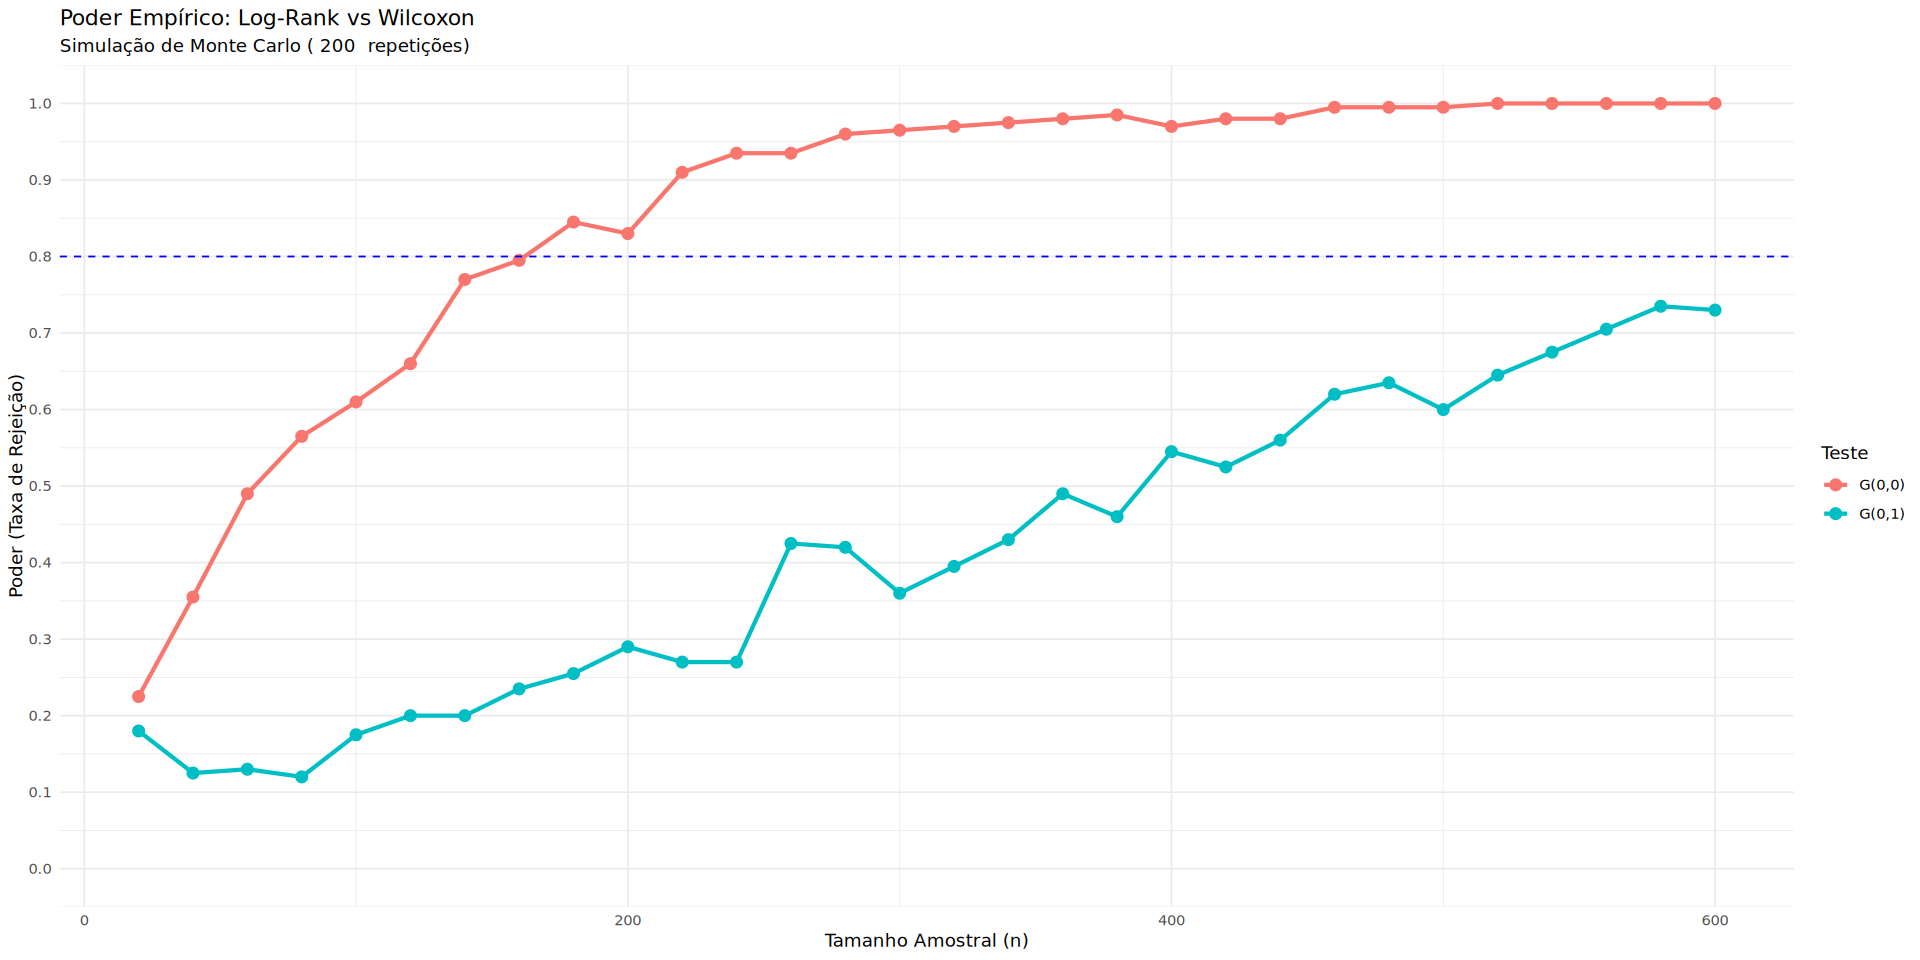

In [5]:
simulacao_amostral_empirica(n_sim = 200, 
                            ns = seq(20, 600, by = 20),
                            rho1 = 0, eta1 = 0,
                            rho2 = 0, eta2 = 1, 
                            alpha = 0.05) 

In [4]:
simulacao_amostral_empirica(n_sim = 200, 
                            ns = seq(20, 600, by = 20),
                            rho1 = 1, eta1 = 0,
                            rho2 = 1, eta2 = 1, 
                            alpha = 0.05) 

Processando n = 20 

=== Relatório | n = 20 ===
Grupo Experimental (A) - Censura Média: 29.8%
Grupo Controle (B) - Censura Média: 27.8%
Processando n = 40 

=== Relatório | n = 40 ===
Grupo Experimental (A) - Censura Média: 28.3%
Grupo Controle (B) - Censura Média: 29.9%
Processando n = 60 

=== Relatório | n = 60 ===
Grupo Experimental (A) - Censura Média: 30.8%
Grupo Controle (B) - Censura Média: 29.4%
Processando n = 80 

=== Relatório | n = 80 ===
Grupo Experimental (A) - Censura Média: 30.4%
Grupo Controle (B) - Censura Média: 30.5%
Processando n = 100 

=== Relatório | n = 100 ===
Grupo Experimental (A) - Censura Média: 29.8%
Grupo Controle (B) - Censura Média: 30.6%
Processando n = 120 

=== Relatório | n = 120 ===
Grupo Experimental (A) - Censura Média: 29.3%
Grupo Controle (B) - Censura Média: 30.0%
Processando n = 140 

=== Relatório | n = 140 ===
Grupo Experimental (A) - Censura Média: 30.5%
Grupo Controle (B) - Censura Média: 30.3%
Processando n = 160 

=== Relatório | n = 

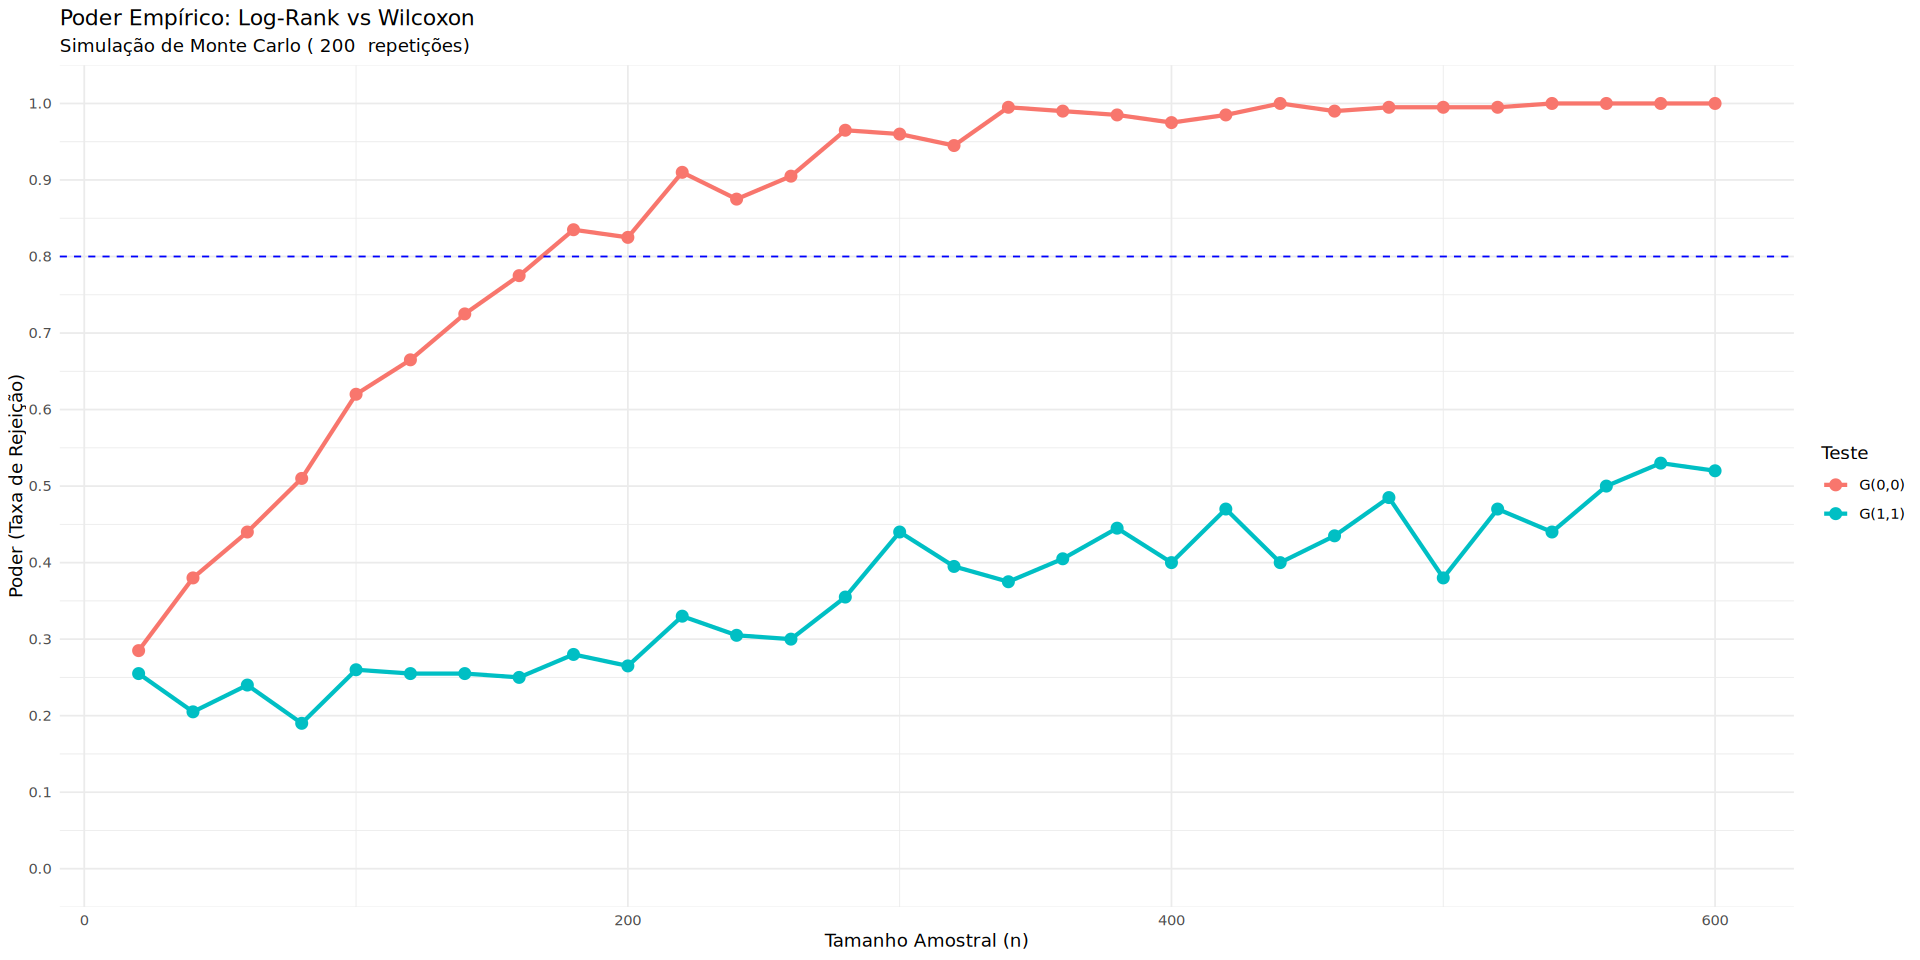

In [3]:
simulacao_amostral_empirica(n_sim = 200, 
                            ns = seq(20, 600, by = 20),
                            rho1 = 0, eta1 = 0,
                            rho2 = 1, eta2 = 1, 
                            alpha = 0.05) 

Processando n = 20 

=== Relatório | n = 20 ===
Grupo Experimental (A) - Censura Média: 29.3%
Grupo Controle (B) - Censura Média: 27.7%
Processando n = 40 

=== Relatório | n = 40 ===
Grupo Experimental (A) - Censura Média: 30.7%
Grupo Controle (B) - Censura Média: 30.5%
Processando n = 60 

=== Relatório | n = 60 ===
Grupo Experimental (A) - Censura Média: 30.0%
Grupo Controle (B) - Censura Média: 29.4%
Processando n = 80 

=== Relatório | n = 80 ===
Grupo Experimental (A) - Censura Média: 29.5%
Grupo Controle (B) - Censura Média: 29.6%
Processando n = 100 

=== Relatório | n = 100 ===
Grupo Experimental (A) - Censura Média: 29.8%
Grupo Controle (B) - Censura Média: 30.3%
Processando n = 120 

=== Relatório | n = 120 ===
Grupo Experimental (A) - Censura Média: 30.6%
Grupo Controle (B) - Censura Média: 30.2%
Processando n = 140 

=== Relatório | n = 140 ===
Grupo Experimental (A) - Censura Média: 30.0%
Grupo Controle (B) - Censura Média: 30.2%
Processando n = 160 

=== Relatório | n = 

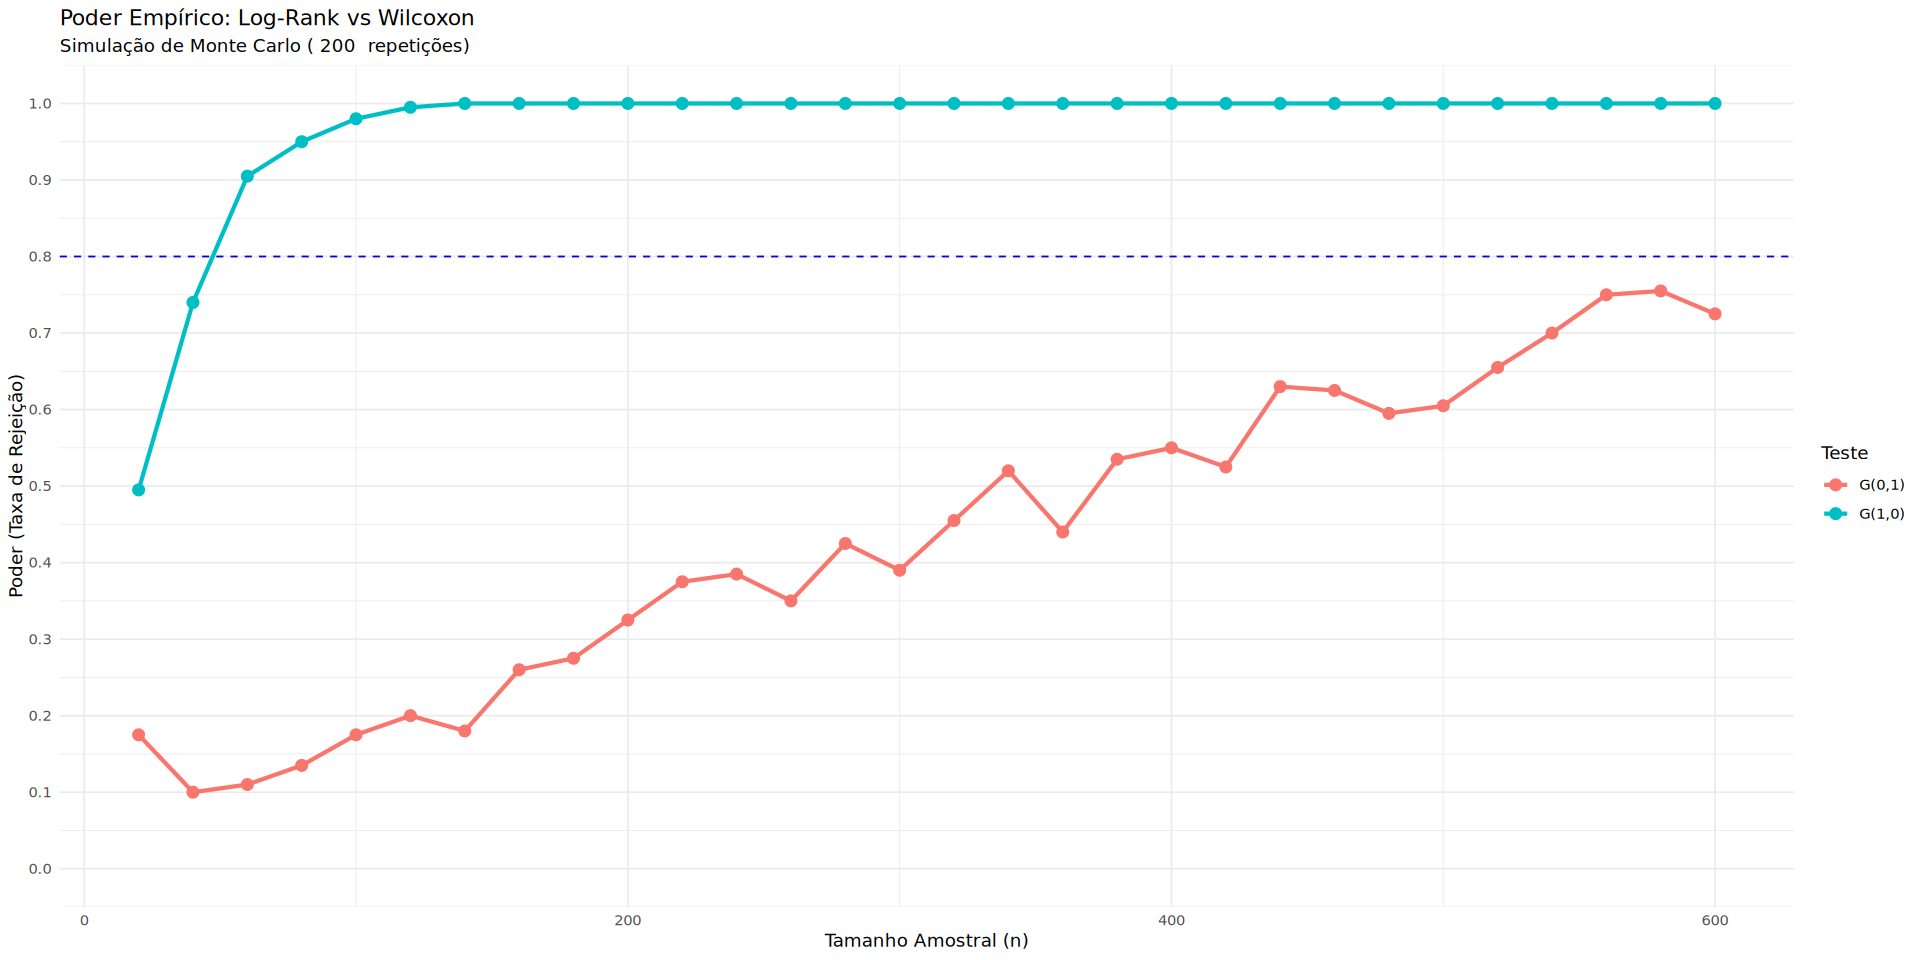

In [6]:
simulacao_amostral_empirica(n_sim = 200, 
                            ns = seq(20, 600, by = 20),
                            rho1 = 1, eta1 = 0,
                            rho2 = 0, eta2 = 1, 
                            alpha = 0.05) 


=== Resumo de Eventos por Intervalo de Tempo (Quantis) ===
     Intervalo Individuos_Totais Falhas Censuras Taxa_Censura_Pct
      0 a 0.06              6667   4666     2001              30%
   0.06 a 0.33              6667   4676     1991            29.9%
   0.33 a 0.85              6666   4610     2056            30.8%
   0.85 a 1.49              6667   4650     2017            30.3%
   1.49 a 2.14              6666   4658     2008            30.1%
   2.14 a 2.85              6667   4659     2008            30.1%
   2.85 a 3.68              6666   4632     2034            30.5%
   3.68 a 4.92              6667   4668     1999              30%
 4.92 a 157.52              6667   4697     1970            29.5%



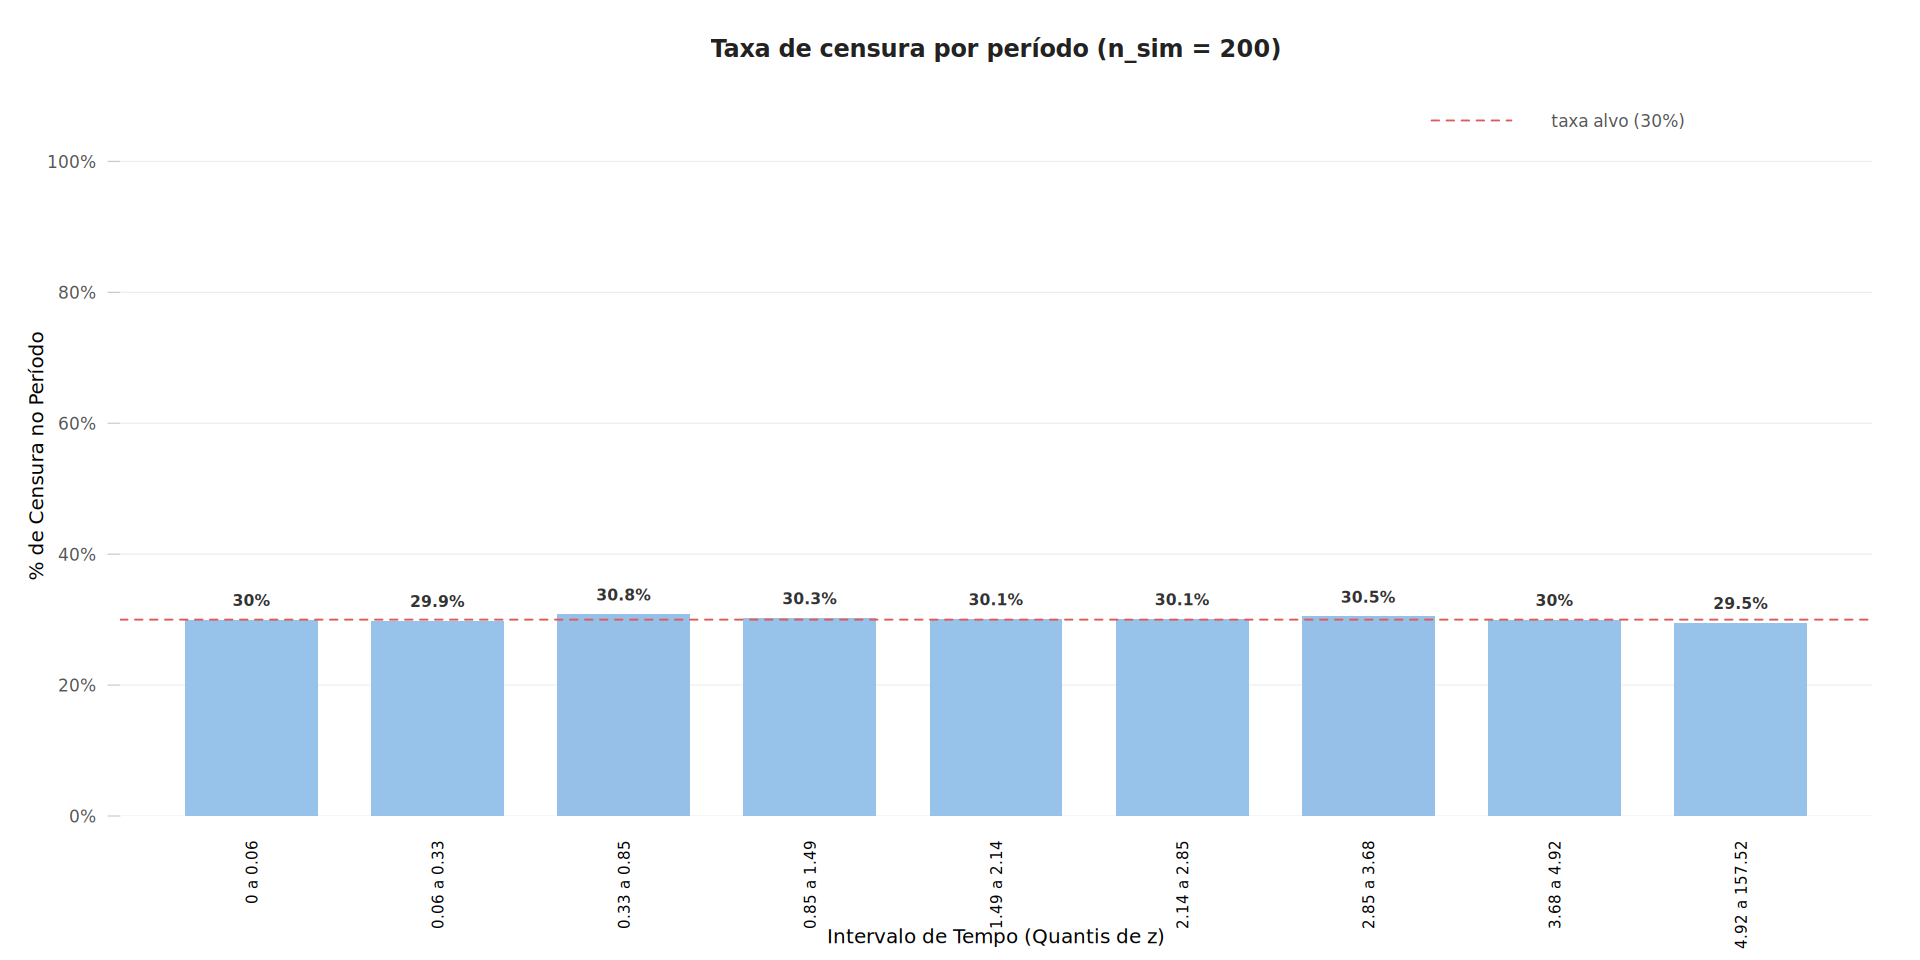

In [5]:
avaliar_perfil_censura_independente(
  n_sim = 200)